            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


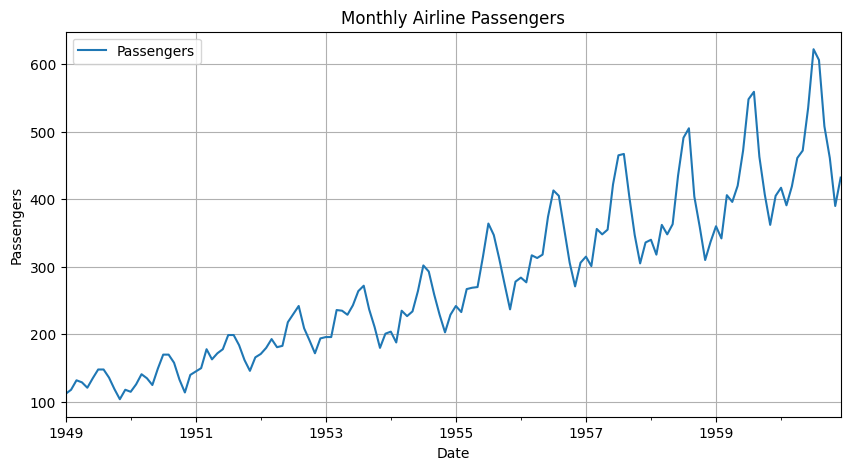

In [ ]:
# 📦 Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from pandas.plotting import autocorrelation_plot

# 📄 Load the dataset (replace with your uploaded file name if needed)
data = pd.read_csv('/content/airline-passengers.csv')

# 🕒 Convert 'Month' to datetime and set as index
data['Month'] = pd.to_datetime(data['Month'])
data.set_index('Month', inplace=True)

# 🔍 Preview the data
print(data.head())
data.plot(figsize=(10, 5), title='Monthly Airline Passengers')
plt.ylabel('Passengers')
plt.xlabel('Date')
plt.grid(True)
plt.show()


In [ ]:
# 📉 Step 2: ADF Test to check stationarity
result = adfuller(data['Passengers'])

print("ADF Test Statistic:", result[0])
print("p-value:", result[1])
for key, value in result[4].items():
    print(f'Critical Value ({key}): {value}')

if result[1] <= 0.05:
    print("✅ The series is stationary (reject null hypothesis)")
else:
    print("⚠️ The series is NOT stationary (fail to reject null hypothesis)")


ADF Test Statistic: 0.8153688792060498
p-value: 0.991880243437641
Critical Value (1%): -3.4816817173418295
Critical Value (5%): -2.8840418343195267
Critical Value (10%): -2.578770059171598
⚠️ The series is NOT stationary (fail to reject null hypothesis)


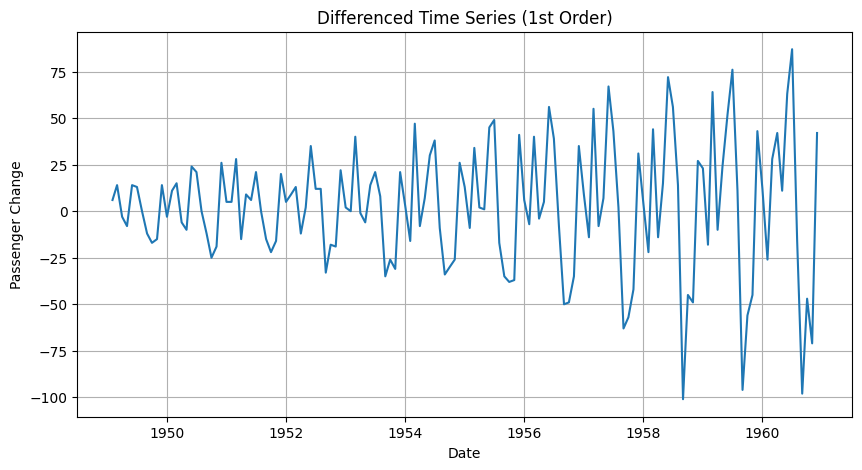

ADF Test Statistic (After Differencing): -2.8292668241700047
p-value: 0.05421329028382478
❌ Series is still not stationary.


In [ ]:
# 🔁 Step 3: First-order differencing
data_diff = data['Passengers'].diff().dropna()

# 📊 Plot the differenced series
plt.figure(figsize=(10, 5))
plt.plot(data_diff)
plt.title('Differenced Time Series (1st Order)')
plt.xlabel('Date')
plt.ylabel('Passenger Change')
plt.grid(True)
plt.show()

# 🔍 Check stationarity again after differencing
result_diff = adfuller(data_diff)
print("ADF Test Statistic (After Differencing):", result_diff[0])
print("p-value:", result_diff[1])
if result_diff[1] <= 0.05:
    print("✅ Series is now stationary.")
else:
    print("❌ Series is still not stationary.")


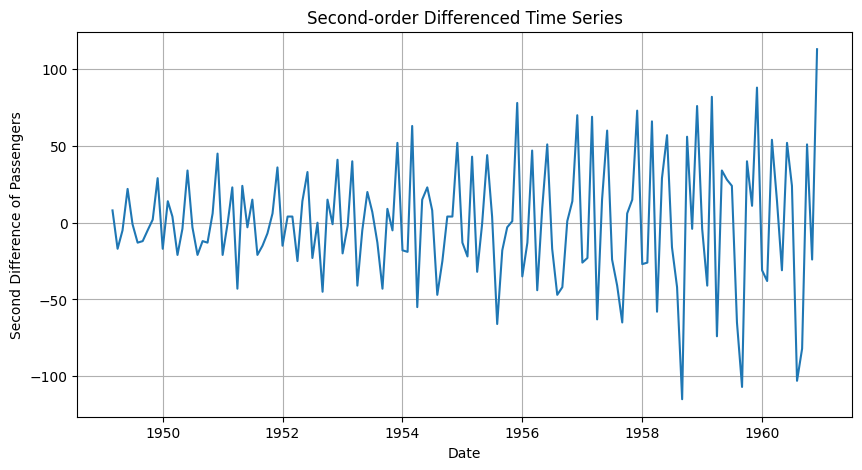

ADF Test Statistic (2nd Diff): -16.384231542468513
p-value: 2.7328918500142026e-29
✅ Now the series is stationary.


In [ ]:
# 🔁 Apply second-order differencing
data_diff2 = data['Passengers'].diff().diff().dropna()

# 📈 Plot second differenced series
plt.figure(figsize=(10, 5))
plt.plot(data_diff2)
plt.title('Second-order Differenced Time Series')
plt.xlabel('Date')
plt.ylabel('Second Difference of Passengers')
plt.grid(True)
plt.show()

# 🔍 ADF test after second differencing
result_diff2 = adfuller(data_diff2)
print("ADF Test Statistic (2nd Diff):", result_diff2[0])
print("p-value:", result_diff2[1])

if result_diff2[1] <= 0.05:
    print("✅ Now the series is stationary.")
else:
    print("❌ Still not stationary.")


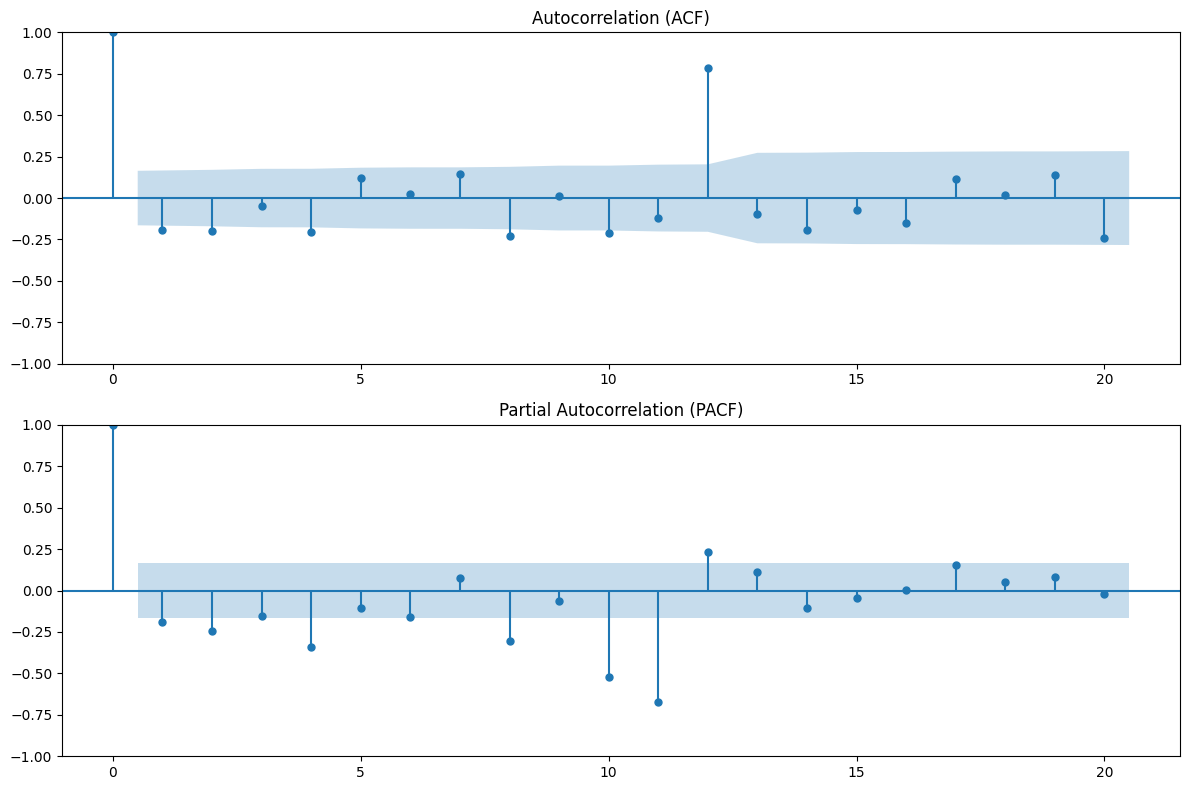

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF and PACF plots
fig, ax = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(data_diff2, ax=ax[0], lags=20)
ax[0].set_title('Autocorrelation (ACF)')

plot_pacf(data_diff2, ax=ax[1], lags=20)
ax[1].set_title('Partial Autocorrelation (PACF)')

plt.tight_layout()
plt.show()


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA(1, 2, 1) model
model = ARIMA(data['Passengers'], order=(1, 2, 1))
model_fit = model.fit()

# Summary of the model
print(model_fit.summary())


/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.11/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:             Passengers   No. Observations:                  144
Model:                 ARIMA(1, 2, 1)   Log Likelihood                -696.464
Date:                Fri, 02 May 2025   AIC                           1398.928
Time:                        16:29:33   BIC                           1407.796
Sample:                    01-01-1949   HQIC                          1402.532
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.3130      0.100      3.127      0.002       0.117       0.509
ma.L1         -0.9998      5.946     -0.168      0.866     -12.655      10.655
sigma2      1034.0044   6187.776      0.167      0.8

<ipython-input-7-4e8e4c44714c>:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  plt.plot(pd.date_range(data.index[-1], periods=forecast_steps + 1, freq='M')[1:], forecast, label='Forecast', color='red')


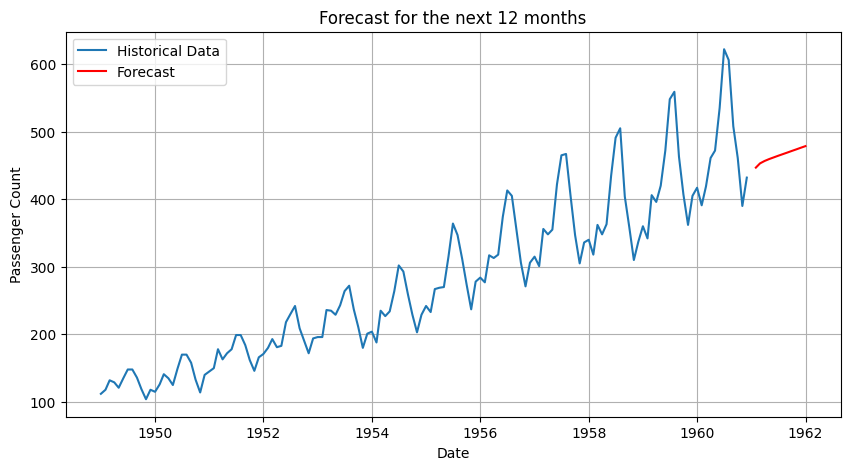

Forecasted Values for next 12 months: 1961-01-01    446.777024
1961-02-01    453.034430
1961-03-01    456.625562
1961-04-01    459.382266
1961-05-01    461.877830
1961-06-01    464.291668
1961-07-01    466.679929
1961-08-01    469.060187
1961-09-01    471.437939
1961-10-01    473.814907
1961-11-01    476.191630
1961-12-01    478.568276
Freq: MS, Name: predicted_mean, dtype: float64


In [ ]:
# Forecasting the next 12 periods
forecast_steps = 12
forecast = model_fit.forecast(steps=forecast_steps)

# Plot the forecasted values
plt.figure(figsize=(10, 5))
plt.plot(data['Passengers'], label='Historical Data')
plt.plot(pd.date_range(data.index[-1], periods=forecast_steps + 1, freq='M')[1:], forecast, label='Forecast', color='red')
plt.title(f'Forecast for the next {forecast_steps} months')
plt.xlabel('Date')
plt.ylabel('Passenger Count')
plt.legend()
plt.grid(True)
plt.show()

# Print the forecasted values
print(f"Forecasted Values for next {forecast_steps} months: {forecast}")


In [ ]:
from sklearn.metrics import mean_squared_error
import numpy as np

# Use the last 'forecast_steps' data points for comparison
y_true = data['Passengers'][-forecast_steps:]
y_pred = forecast

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_true, y_pred))
print(f"RMSE for the forecast: {rmse:.2f}")


RMSE for the forecast: 73.73
